<a href="https://colab.research.google.com/github/jorge-pichardo07/EDP1/blob/main/Pr%C3%A1ctica_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRUEBA DE FRECUENCIAS**
ELABORADO POR: JORGE LUIS MAGAÑA PICHARDO

Importé las librerías numpy, matplotlib

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tabulate import tabulate

La lista de datos generados, de la tabla 3.1 del libro

In [54]:
datos = [
0.78961, 0.05230, 0.10699, 0.55877, 0.14151,
0.76086, 0.12079, 0.27738, 0.65726, 0.79269,
0.80548, 0.82654, 0.29453, 0.20852, 0.42989,
0.58518, 0.98611, 0.34488, 0.34358, 0.11537,
0.89898, 0.57880, 0.67621, 0.05010, 0.00121,
0.28269, 0.73059, 0.70119, 0.18284, 0.49962,
0.38618, 0.76910, 0.68334, 0.55170, 0.10850,
0.79882, 0.45679, 0.21631, 0.87616, 0.55743,
0.58962, 0.33216, 0.03185, 0.61168, 0.09264,
0.69623, 0.17028, 0.05475, 0.91512, 0.76262,
0.29931, 0.30861, 0.83358, 0.51781, 0.03272,
0.57410, 0.26593, 0.85903, 0.43308, 0.35286,
0.24000, 0.65559, 0.38507, 0.90829, 0.94187,
0.93655, 0.88809, 0.81772, 0.36982, 0.19904,
0.54325, 0.62400, 0.09133, 0.41678, 0.33954,
0.58244, 0.85853, 0.86752, 0.38729, 0.15506,
0.23949, 0.53559, 0.33381, 0.49883, 0.75103,
0.19962, 0.65002, 0.74579, 0.79113, 0.63453,
0.19147, 0.40644, 0.08128, 0.73435, 0.22724,
0.22287, 0.07281, 0.64183, 0.44267, 0.72102
]

Elaboramos la tabla de frecuencias, primero el intervalo de frecuencias, tomamos:
\
(0 a 0.2]
\
(0.2 a 0.4]
\
(0.4 a 0.6]
\
(0.6 a 0.8]
\
(0.8 a 1.01]



Aqui contamos el numero de veces que apareció el dato en el intervalo

In [55]:

bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
# Clasificar datos en intervalos
indices = np.digitize(datos, bins, right=False)
# Contar cuántos hay en cada intervalo
conteos = [(indices == i).sum() for i in range(1, len(bins))]


Generamos la tabla, con la frecuencia observada y la frecuencia esperada dada por $$\frac{Datos}{Numero\: de\: Intervalos}$$

In [56]:

# Crear tabla comparativa
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
inter = ['(0, 0.2]', '(0.2, 0.4]','(0.4, 0.6]','(0.6, 0.8]','(0.8, 1.01]' ]
veo =[]
for i in range(len(conteos)):
  veo.append(20)
avr = []
for i in range(len(conteos)):
  avr.append((conteos[i] - veo[i])**2/veo[i])

tabla = [[int(i+1),inter[i], conteos[i], veo[i], avr[i] ] for i in range(len(conteos))]
print(tabulate(tabla,
               headers=['Intervalo','Intervalos', 'Frecuencia observada', 'Frecuencia Esperada', 'Estadistico'],
               tablefmt='grid', numalign='center'))

+-------------+--------------+------------------------+-----------------------+---------------+
|  Intervalo  | Intervalos   |  Frecuencia observada  |  Frecuencia Esperada  |  Estadistico  |
+=============+==============+========================+=======================+===============+
|      1      | (0, 0.2]     |           21           |          20           |     0.05      |
+-------------+--------------+------------------------+-----------------------+---------------+
|      2      | (0.2, 0.4]   |           22           |          20           |      0.2      |
+-------------+--------------+------------------------+-----------------------+---------------+
|      3      | (0.4, 0.6]   |           19           |          20           |     0.05      |
+-------------+--------------+------------------------+-----------------------+---------------+
|      4      | (0.6, 0.8]   |           23           |          20           |     0.45      |
+-------------+--------------+----------

Generamos la gráfica de las frecuencias observadas y la linea marcada de rojo, es la frecuencia observada

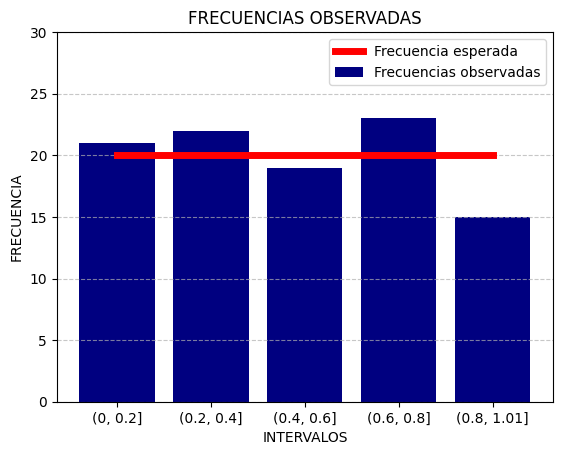

In [71]:
from matplotlib.lines import lineStyles
plt.title("FRECUENCIAS OBSERVADAS")
plt.bar(inter,conteos, color = 'navy', label = 'Frecuencias observadas')
plt.xlabel('INTERVALOS')
plt.ylabel('FRECUENCIA')
plt.plot(inter, veo, color ='red', linewidth = 5, label = 'Frecuencia esperada')
plt.ylim(0, 30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

Hacemos la suma del estádistico $Z$, y posteriormente comparo con la $Z_0$, para hacer la prueba de HIPÓTESIS

In [79]:
Z = 0
for i in range(len(conteos)):
 Z += avr[i]
# Grados de libertad (df = número de intervalos - 1)
k = len(conteos) - 1
#Asumimos confianza de 95%
alpha = 0.05
Z_0 = stats.chi2.ppf(1 - alpha, df)
# Comparamos z con z_0
if Z < Z_0:
    print(f"Como {Z:.2f} < {Z_0:.2f}, no se rechaza la hipótesis nula. Los datos se ajustan a la distribución unitaria.")
else:
    print(f"Como {Z:.2f} >= {Z_0:.2f}, se rechaza la hipótesis nula. Los datos no se ajustan a la distribución unitaria.")

Como 2.00 < 9.49, no se rechaza la hipótesis nula. Los datos se ajustan a la distribución unitaria.
